# Capstone Project: Handwritten Digit Classification using CNN

This notebook implements a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset.

**Project outputs generated by this notebook after execution:**

- trained model file: `models/mnist_cnn_model.keras`
- training history file: `results/training_history.csv`
- loss plot: `results/loss_curve.png`
- accuracy plot: `results/accuracy_curve.png`
- classification report: `results/classification_report.txt`
- confusion matrix image: `results/confusion_matrix.png`

The final test-set evaluation is placed in a separate cell for easy verification, as required by the capstone guidelines.


In [24]:
import sys
print(sys.executable)
print(sys.version)

/Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/minst_env/bin/python3
3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]


## 1. Problem Statement

The goal of this project is to build a deep learning model that can automatically classify grayscale handwritten digit images into one of ten classes: digits 0 through 9.

This is a multiclass image classification problem. Each input image is a 28 x 28 grayscale image, and the model predicts the most likely digit class.

In [25]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from PIL import Image

print("TensorFlow:", tf.__version__)
print("All imports OK")

TensorFlow: 2.21.0
All imports OK


## 2. Import Libraries

In [26]:
# Core libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras libraries
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Image preprocessing for external inference
from PIL import Image

# Reproducibility
np.random.seed(22)

# Make notebook outputs save to the repository root, even when Jupyter runs from notebooks/.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
SAMPLE_IMAGES_DIR = PROJECT_ROOT / "sample_images"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)


Project root: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN
Models directory: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/models
Results directory: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results


## 3. Load Dataset

The MNIST dataset contains 60,000 training images and 10,000 test images of handwritten digits. Each image is grayscale and has a size of 28 x 28 pixels.

In [27]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 4. Dataset Exploration

In [28]:
# Check class distribution in training and testing data
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Train label distribution:")
print(dict(zip(unique_train, counts_train)))

print("Test label distribution:")
print(dict(zip(unique_test, counts_test)))

Train label distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
Test label distribution:
{np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


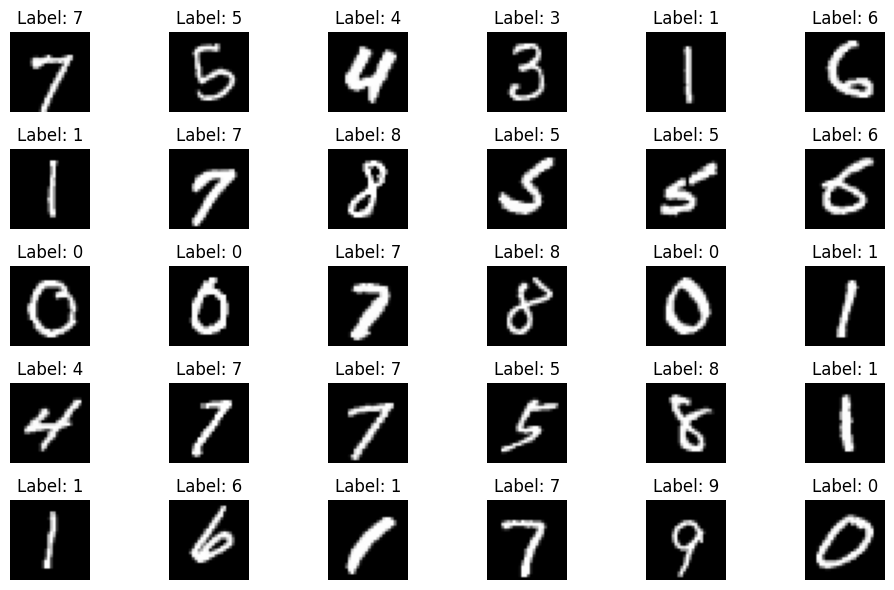

In [29]:
# Visualize random sample images from the training set
plt.figure(figsize=(10, 6))
random_indices = np.random.randint(0, x_train.shape[0], size=30)

for i, idx in enumerate(random_indices):
    plt.subplot(5, 6, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

The images are reshaped from `(samples, 28, 28)` to `(samples, 28, 28, 1)` because CNN layers expect a channel dimension.

Pixel values are normalized from the range `0-255` to `0-1` to make model training more stable.

In [30]:
# Reshape images to include the grayscale channel dimension
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32")
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32")

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)
Pixel value range: 0.0 to 1.0


## 6. Label Encoding

The labels are converted into one-hot encoded vectors because the output layer has 10 neurons and uses softmax activation.

In [31]:
# Convert integer labels into one-hot encoded labels
y_cat_train = to_categorical(y_train, num_classes=10)
y_cat_test = to_categorical(y_test, num_classes=10)

print("Original label example:", y_train[0])
print("One-hot encoded example:", y_cat_train[0])

Original label example: 5
One-hot encoded example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 7. Dataset Split

The original MNIST training set is split into training and validation subsets:

- 80% of the original training data is used for training.
- 20% of the original training data is used for validation.
- The official MNIST test set is used only for final evaluation.

This prevents the test set from influencing model training decisions.

In [32]:
# Create a validation split from the training data
x_train_final, x_valid, y_train_final, y_valid = train_test_split(
    x_train,
    y_cat_train,
    test_size=0.2,
    random_state=22,
    stratify=y_train
)

print("Final training data:", x_train_final.shape)
print("Validation data:", x_valid.shape)
print("Test data:", x_test.shape)

Final training data: (48000, 28, 28, 1)
Validation data: (12000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


## 8. Build CNN Model

The model uses a simple CNN architecture suitable for grayscale digit recognition:

| Layer | Purpose |
|---|---|
| Conv2D | Extracts local visual patterns such as edges, curves, and strokes |
| MaxPool2D | Reduces spatial size and keeps the strongest features |
| Flatten | Converts feature maps into a one-dimensional vector |
| Dense | Learns high-level digit patterns |
| Dropout | Reduces overfitting |
| Dense Softmax | Outputs probabilities for 10 digit classes |

In [33]:
# Build CNN model
model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(4, 4),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(10, activation="softmax"))

model.summary()

/Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/minst_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile Model

The model is compiled using:

- **Loss function:** categorical crossentropy
- **Optimizer:** Adam
- **Metric:** accuracy

Categorical crossentropy is appropriate because this is a multiclass classification problem with one-hot encoded labels.

In [34]:
# Compile model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

## 10. Train Model

Early stopping is used to stop training when validation loss no longer improves. `restore_best_weights=True` ensures the model keeps the best-performing weights from training.

In [35]:
# Define early stopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    x_train_final,
    y_train_final,
    epochs=5,
    batch_size=128,
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop]
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9164 - loss: 0.2852 - val_accuracy: 0.9734 - val_loss: 0.0912
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9735 - loss: 0.0887 - val_accuracy: 0.9811 - val_loss: 0.0607
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9805 - loss: 0.0642 - val_accuracy: 0.9843 - val_loss: 0.0512
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9852 - loss: 0.0497 - val_accuracy: 0.9855 - val_loss: 0.0470
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9842 - val_loss: 0.0482


## 11. Save Training History and Visualizations

In [36]:
# Convert training history into a DataFrame
history_df = pd.DataFrame(history.history)

# Save history as CSV so results remain available after notebook execution
history_path = RESULTS_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training history saved to:", history_path)
history_df


Training history saved to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results/training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.916396,0.285248,0.973417,0.091214
1,0.973500,0.088673,0.981083,0.060657
2,0.980500,0.064241,0.984333,0.051173
3,0.985187,0.049719,0.985500,0.047030
4,0.987771,0.039671,0.984167,0.048165


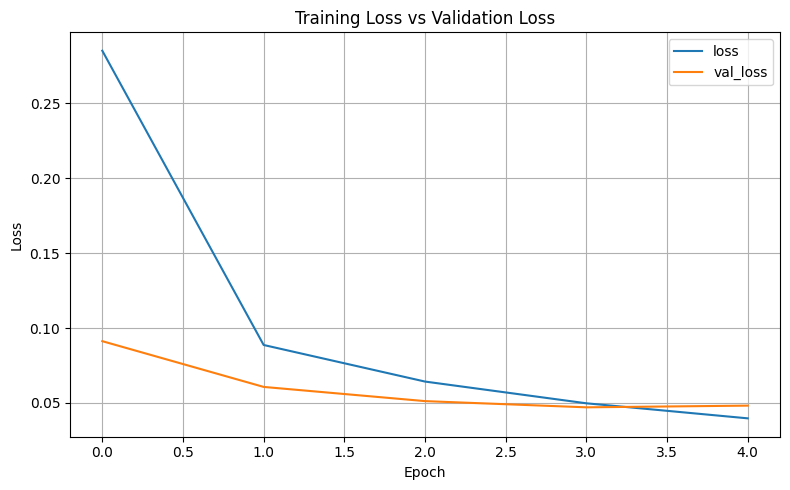

Loss curve saved to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results/loss_curve.png


In [37]:
# Plot and save training vs validation loss
loss_curve_path = RESULTS_DIR / "loss_curve.png"

fig, ax = plt.subplots(figsize=(8, 5))
history_df[["loss", "val_loss"]].plot(ax=ax)
ax.set_title("Training Loss vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True)
fig.tight_layout()
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("Loss curve saved to:", loss_curve_path)


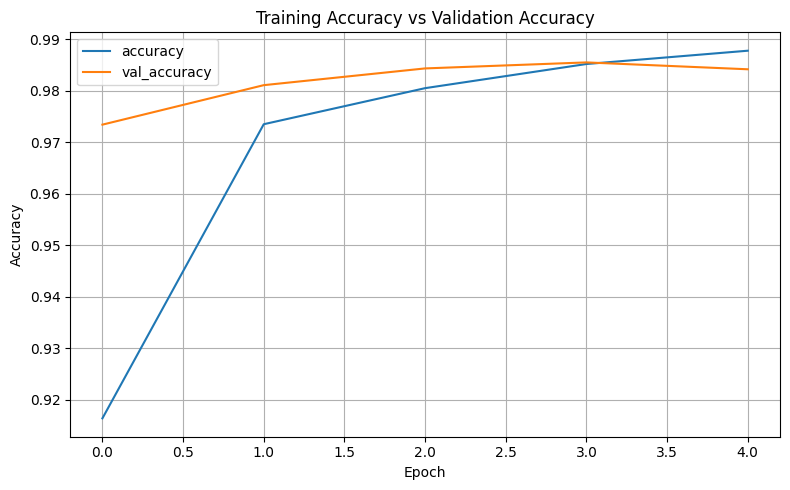

Accuracy curve saved to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results/accuracy_curve.png


In [38]:
# Plot and save training vs validation accuracy
accuracy_curve_path = RESULTS_DIR / "accuracy_curve.png"

fig, ax = plt.subplots(figsize=(8, 5))
history_df[["accuracy", "val_accuracy"]].plot(ax=ax)
ax.set_title("Training Accuracy vs Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid(True)
fig.tight_layout()
fig.savefig(accuracy_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:", accuracy_curve_path)


## 12. Final Test Set Evaluation

This cell evaluates the trained model on the official MNIST test set. It is intentionally separated for easy verification.

In [39]:
# Final evaluation on test data
test_loss, test_accuracy = model.evaluate(x_test, y_cat_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9865 - loss: 0.0390
Test Loss: 0.039006806910037994
Test Accuracy: 0.9865000247955322


## 13. Classification Report and Confusion Matrix

In [40]:
# Generate predictions for the test set
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Create and save classification report
report = classification_report(y_test, y_pred_classes)
print(report)

classification_report_path = RESULTS_DIR / "classification_report.txt"
classification_report_path.write_text(report, encoding="utf-8")
print("Classification report saved to:", classification_report_path)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Classification report saved to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results/classification_report.txt


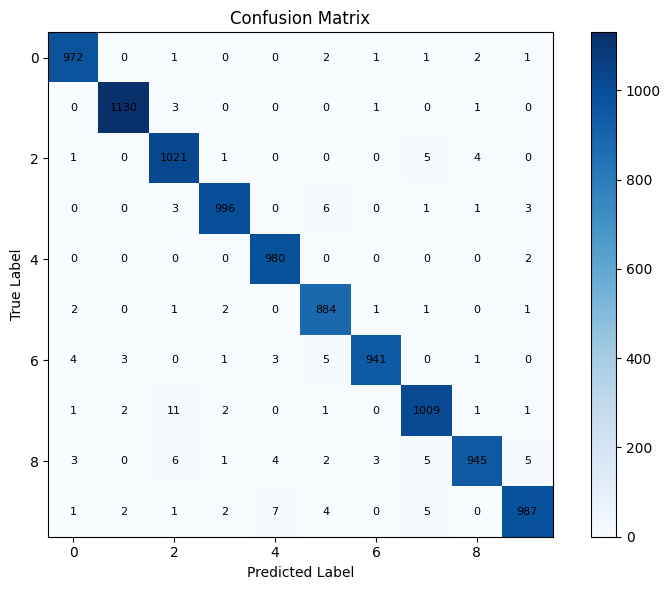

Confusion matrix saved to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/results/confusion_matrix.png


In [41]:
# Create and save confusion matrix visualization
confusion_matrix_path = RESULTS_DIR / "confusion_matrix.png"
cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.colorbar(im, ax=ax)

for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

fig.tight_layout()
fig.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)


## 14. Save and Export Model

The trained model is saved in the modern Keras `.keras` format. This file contains the model architecture, learned weights, and optimizer state.

In [42]:
# Save the complete trained model
model_path = MODELS_DIR / "mnist_cnn_model.keras"
model.save(model_path)

print("Model saved successfully to:", model_path)


Model saved successfully to: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/models/mnist_cnn_model.keras


## 15. Load Saved Model

In [43]:
# Load the saved model for reuse without retraining
model_path = MODELS_DIR / "mnist_cnn_model.keras"
loaded_model = load_model(model_path)

print("Saved model loaded successfully from:", model_path)


Saved model loaded successfully from: /Users/himanshuair/Documents/itt-d assignment/IITD Project/github repo/Digit-recognition-using-CNN/models/mnist_cnn_model.keras


## 16. Single Test Image Inference

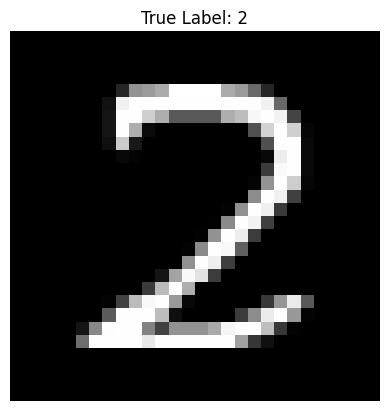

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
True Label: 2
Predicted Label: 2
Confidence: 0.9998816


In [44]:
# Predict one image from the MNIST test set
image_index = 225

sample_image = x_test[image_index]
true_label = y_test[image_index]

plt.imshow(sample_image.reshape(28, 28), cmap="gray")
plt.title(f"True Label: {true_label}")
plt.axis("off")
plt.show()

sample_image_input = sample_image.reshape(1, 28, 28, 1)
prediction_probs = loaded_model.predict(sample_image_input)
predicted_label = np.argmax(prediction_probs)
confidence = np.max(prediction_probs)

print("True Label:", true_label)
print("Predicted Label:", predicted_label)
print("Confidence:", confidence)

## 17. External Image Prediction Function

Use this function to predict a digit from an external image such as `my_digit.png`.

The image is converted to grayscale, resized to 28 x 28, normalized, optionally inverted, and reshaped before prediction.

Use `invert=True` when the image has a black digit on a white background.

In [45]:
def predict_digit_from_image(img_path, model, invert=True):
    """
    Predicts a handwritten digit from an external image file.

    Parameters:
    img_path (str): Path to the image file.
    model: Loaded Keras model.
    invert (bool): Use True for black digit on white background.

    Returns:
    int: Predicted digit.
    """
    # Load image and convert to grayscale
    img = Image.open(img_path).convert("L")

    # Resize to MNIST input size
    img = img.resize((28, 28))

    # Convert image to numeric array and normalize
    img_array = np.array(img).astype("float32") / 255.0

    # Invert image if external image has black digit on white background
    if invert:
        img_array = 1.0 - img_array

    # Display processed image
    plt.imshow(img_array, cmap="gray")
    plt.title("Processed Input Image")
    plt.axis("off")
    plt.show()

    # Reshape for CNN input
    img_array = img_array.reshape(1, 28, 28, 1)

    # Predict digit
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction)

    print("Predicted Digit:", predicted_digit)
    print("Confidence:", confidence)

    return predicted_digit

In [46]:
# Example usage after placing an external image in sample_images/:
# predict_digit_from_image(SAMPLE_IMAGES_DIR / "my_digit.png", loaded_model, invert=True)


## 18. Suggested Improvements

Future improvements can include:

1. Train on Fashion-MNIST or EMNIST for a more challenging image classification task.
2. Add a second convolutional block to improve feature extraction.
3. Use data augmentation such as small rotations and shifts, but avoid horizontal flips for digits.
4. Analyze misclassified images to understand model weaknesses.
5. Build a simple Flask or Streamlit app to upload an image and return the predicted digit.
6. Test the model on self-created handwritten digit images to evaluate real-world robustness.